# Projet COVID 19 : Modelisation Random Forest - 4 classes - Balanced - 3ème itération

## Conditions de modélisation

## Environnement de travail

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve,
    average_precision_score
)

from sklearn.inspection import permutation_importance
import joblib

In [5]:
# Répertoire du notebook
NOTEBOOK_DIR = Path.cwd()

# Dossier du projet COVID
PROJECT_DIR = NOTEBOOK_DIR.parent.parent.parent

# Dossier contenant les CSV de features à 3 classes
DATA_DIR = PROJECT_DIR / "features"

print("Notebook :", NOTEBOOK_DIR)
print("Projet   :", PROJECT_DIR)
print("CSV      :", DATA_DIR)
print("Dossier trouvé :", DATA_DIR.exists())

Notebook : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\Liora_Covid\models\random_forest
Projet   : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID
CSV      : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\features
Dossier trouvé : True


In [6]:
# Chargement des données — analyse à 3 classes

train = pd.read_csv(
    DATA_DIR / "train_features_3classes.csv"
)

validation = pd.read_csv(
    DATA_DIR / "validation_features_3classes.csv"
)

test = pd.read_csv(
    DATA_DIR / "test_features_3classes.csv"
)

print(f"\nTrain      : {train.shape}")
print(f"Validation : {validation.shape}")
print(f"Test       : {test.shape}")


Train      : (16668, 6)
Validation : (2083, 6)
Test       : (2084, 6)


## Définition de la cible et des features

In [7]:
target = "classe"

features = [
    "lum_interieur_masque",
    "lum_exterieur_masque",
    "surface_masque",
    "variance_laplacien"
]

target = "classe"

X_train = train[features]
y_train = train[target]

X_val = validation[features]
y_val = validation[target]

X_test = test[features]
y_test = test[target]

## Vérification des classes

In [8]:
print("Distribution train :")
print(y_train.value_counts(normalize=True))

print("\nDistribution validation :")
print(y_val.value_counts(normalize=True))

print("\nDistribution test :")
print(y_test.value_counts(normalize=True))

Distribution train :
classe
Normal       0.486501
Pneumonia    0.351632
COVID        0.161867
Name: proportion, dtype: float64

Distribution validation :
classe
Normal       0.486318
Pneumonia    0.351416
COVID        0.162266
Name: proportion, dtype: float64

Distribution test :
classe
Normal       0.486564
Pneumonia    0.351727
COVID        0.161708
Name: proportion, dtype: float64


## Pipeline Random Forest

In [9]:
rf_pipe = Pipeline([
    ("model", RandomForestClassifier(
        random_state=0,
        class_weight="balanced",
        n_jobs=-1
    ))
])

## Grille des Hyperparamètres

In [10]:
param_grid_v3 = {
    "model__n_estimators": [200],
    "model__max_depth": [15, 20, 25],
    "model__min_samples_split": [10, 15, 20],
    "model__min_samples_leaf": [2, 3, 4, 5],
    "model__max_features": ["sqrt"]
}

## Cross-validation stratifiée + GridSearch

In [11]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)

grid_rf = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_v3,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_rf.fit(X_train, y_train)


Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_jobs=-1,
                                                               random_state=0))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [15, 20, 25],
                         'model__max_features': ['sqrt'],
                         'model__min_samples_leaf': [2, 3, 4, 5],
                         'model__min_samples_split': [10, 15, 20],
                         'model__n_estimators': [200]},
             return_train_score=True, scoring='f1_macro', verbose=1)

In [12]:
# Meilleurs paramètres

print("Meilleurs paramètres :")
print(grid_rf.best_params_)

print("\nMeilleur score F1 moyen en cross-validation :")
print(grid_rf.best_score_)

Meilleurs paramètres :
{'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 15, 'model__n_estimators': 200}

Meilleur score F1 moyen en cross-validation :
0.5200753262755112


In [13]:
# Résultats de la GridSearch

results = pd.DataFrame(grid_rf.cv_results_)
results = results.sort_values("rank_test_score")

results[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "params"
]].head(10)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,params
10,1,0.520075,0.007827,0.773410,0.001948,"{'model__max_depth': 15, 'model__max_features'..."
11,2,0.519325,0.006734,0.750092,0.002731,"{'model__max_depth': 15, 'model__max_features'..."
35,3,0.518252,0.007548,0.785765,0.002412,"{'model__max_depth': 25, 'model__max_features'..."
7,4,0.518075,0.006301,0.782294,0.002306,"{'model__max_depth': 15, 'model__max_features'..."
5,5,0.517671,0.007292,0.761379,0.001997,"{'model__max_depth': 15, 'model__max_features'..."
17,6,0.517223,0.008403,0.797991,0.002635,"{'model__max_depth': 20, 'model__max_features'..."
23,7,0.516615,0.008458,0.780209,0.002163,"{'model__max_depth': 20, 'model__max_features'..."
6,8,0.516250,0.007907,0.814537,0.003046,"{'model__max_depth': 15, 'model__max_features'..."
2,9,0.516201,0.007417,0.766737,0.001629,"{'model__max_depth': 15, 'model__max_features'..."
1,10,0.516131,0.007503,0.797723,0.002319,"{'model__max_depth': 15, 'model__max_features'..."


## Évaluation sur validation

### Classification report

In [14]:
best_rf = grid_rf.best_estimator_

y_val_pred = best_rf.predict(X_val)
y_val_proba = best_rf.predict_proba(X_val)

print("Évaluation sur le jeu de validation")
print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Balanced accuracy :", balanced_accuracy_score(y_val, y_val_pred))
print("Precision macro :", precision_score(y_val, y_val_pred, average="macro"))
print("Recall macro :", recall_score(y_val, y_val_pred, average="macro"))
print("F1-score macro :", f1_score(y_val, y_val_pred, average="macro"))
print("F1-score weighted :", f1_score(y_val, y_val_pred, average="weighted"))

print("\nRapport de classification :")
print(classification_report(y_val, y_val_pred))

Évaluation sur le jeu de validation
Accuracy : 0.6101776284205472
Balanced accuracy : 0.5170784032579431
Precision macro : 0.5184713145825148
Recall macro : 0.5170784032579431
F1-score macro : 0.5153716988245054
F1-score weighted : 0.5990967105596059

Rapport de classification :
              precision    recall  f1-score   support

       COVID       0.26      0.18      0.21       338
      Normal       0.69      0.74      0.71      1013
   Pneumonia       0.61      0.63      0.62       732

    accuracy                           0.61      2083
   macro avg       0.52      0.52      0.52      2083
weighted avg       0.59      0.61      0.60      2083



### Matrice de confusion

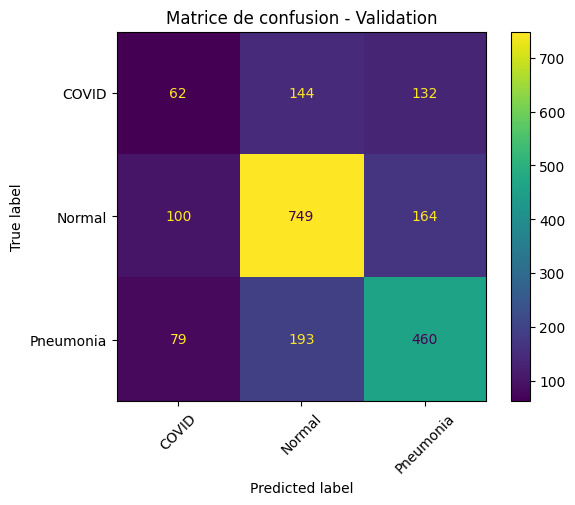

In [15]:
cm = confusion_matrix(y_val, y_val_pred)
class_names = best_rf.named_steps["model"].classes_

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion - Validation")
plt.show()

### Features importance

In [16]:
rf_model = best_rf.named_steps["model"]

importances = rf_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
3,variance_laplacien,0.381877
2,surface_masque,0.244660
0,lum_interieur_masque,0.203670
1,lum_exterieur_masque,0.169794


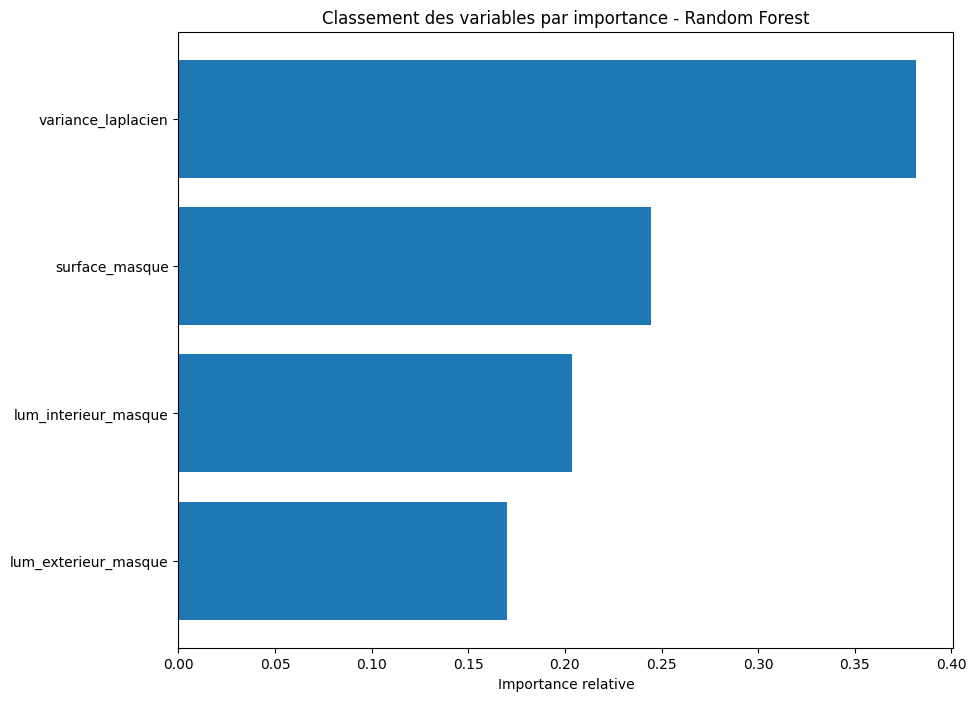

In [17]:
plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance_df["feature"][::-1],
    feature_importance_df["importance"][::-1]
)
plt.xlabel("Importance relative")
plt.title("Classement des variables par importance - Random Forest")
plt.show()

### Permutation importance

In [18]:
perm_importance = permutation_importance(
    best_rf,
    X_val,
    y_val,
    scoring="f1_macro",
    n_repeats=10,
    random_state=0,
    n_jobs=-1
)

In [19]:
perm_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
})

perm_df = perm_df.sort_values(
    by="importance_mean",
    ascending=False
).reset_index(drop=True)

perm_df.head(20)

,feature,importance_mean,importance_std
0,variance_laplacien,0.146372,0.012553
1,surface_masque,0.062490,0.010531
2,lum_interieur_masque,0.016690,0.007077
3,lum_exterieur_masque,-0.000338,0.002347


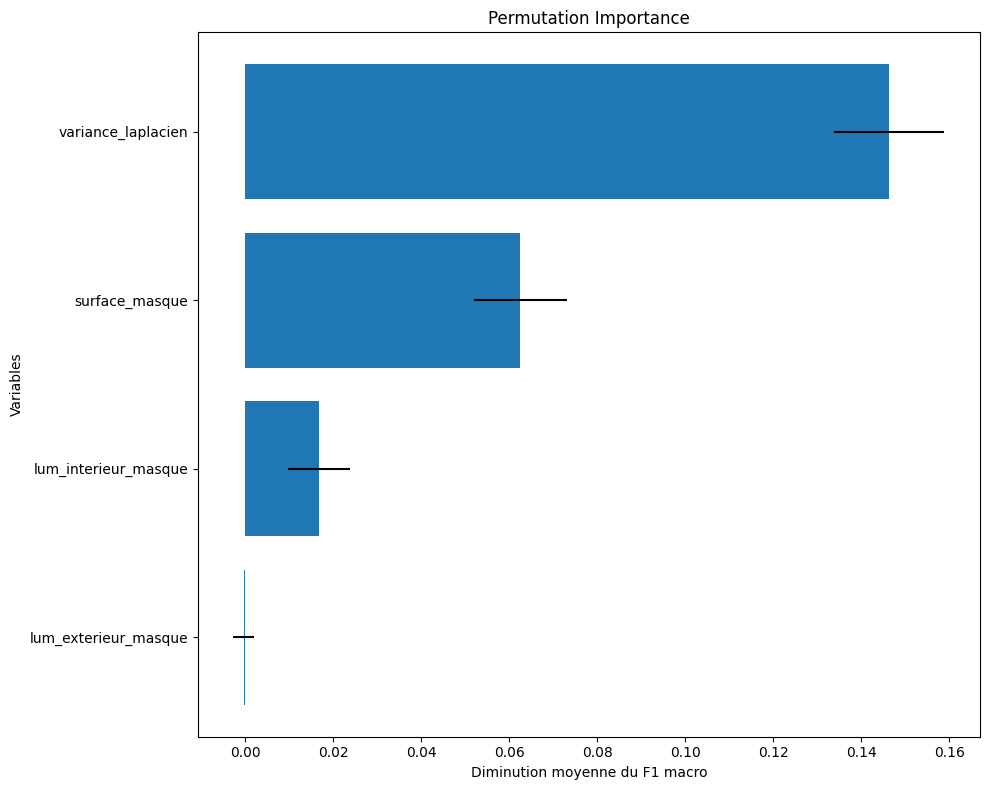

In [20]:
plt.figure(figsize=(10,8))

plt.barh(
    perm_df["feature"][:20][::-1],
    perm_df["importance_mean"][:20][::-1],
    xerr=perm_df["importance_std"][:20][::-1]
)

plt.xlabel("Diminution moyenne du F1 macro")
plt.ylabel("Variables")
plt.title("Permutation Importance")

plt.tight_layout()
plt.show()

In [21]:
# Ordre exact des classes dans les colonnes de predict_proba
class_names = best_rf.classes_

print("Ordre des classes :", class_names)
print("Forme de y_val_proba :", y_val_proba.shape)
print("Nombre d'observations :", len(y_val))

assert y_val_proba.shape[0] == len(y_val)
assert y_val_proba.shape[1] == len(class_names)

Ordre des classes : ['COVID' 'Normal' 'Pneumonia']
Forme de y_val_proba : (2083, 3)
Nombre d'observations : 2083


## Test du modèle

### Classification report

In [22]:
final_model = best_rf

y_test_pred = final_model.predict(X_test)

print("Évaluation finale sur le jeu de test")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Balanced accuracy :", balanced_accuracy_score(y_test, y_test_pred))
print("Precision macro :", precision_score(y_test, y_test_pred, average="macro"))
print("Recall macro :", recall_score(y_test, y_test_pred, average="macro"))
print("F1-score macro :", f1_score(y_test, y_test_pred, average="macro"))
print("F1-score weighted :", f1_score(y_test, y_test_pred, average="weighted"))

print("\nRapport de classification :")
print(classification_report(y_test, y_test_pred))

Évaluation finale sur le jeu de test
Accuracy : 0.6041266794625719
Balanced accuracy : 0.5206102704840744
Precision macro : 0.5260094876569373
Recall macro : 0.5206102704840744
F1-score macro : 0.521478466193304
F1-score weighted : 0.5960896126966718

Rapport de classification :
              precision    recall  f1-score   support

       COVID       0.31      0.23      0.27       337
      Normal       0.69      0.74      0.71      1014
   Pneumonia       0.58      0.59      0.58       733

    accuracy                           0.60      2084
   macro avg       0.53      0.52      0.52      2084
weighted avg       0.59      0.60      0.60      2084



### Matrice de confusion

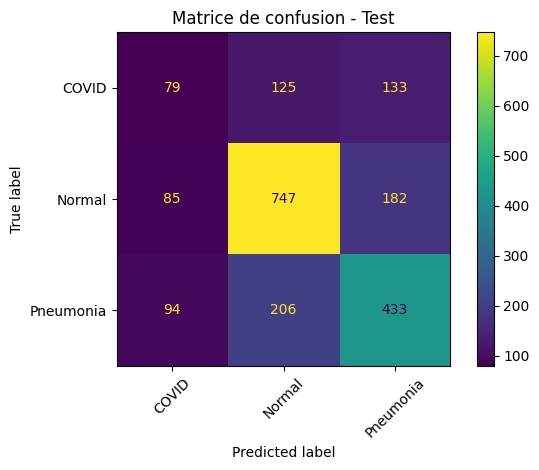

In [23]:
cm_test = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=final_model.classes_
)

disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion - Test")
plt.tight_layout()
plt.show()

## Courbes Precision / Recall

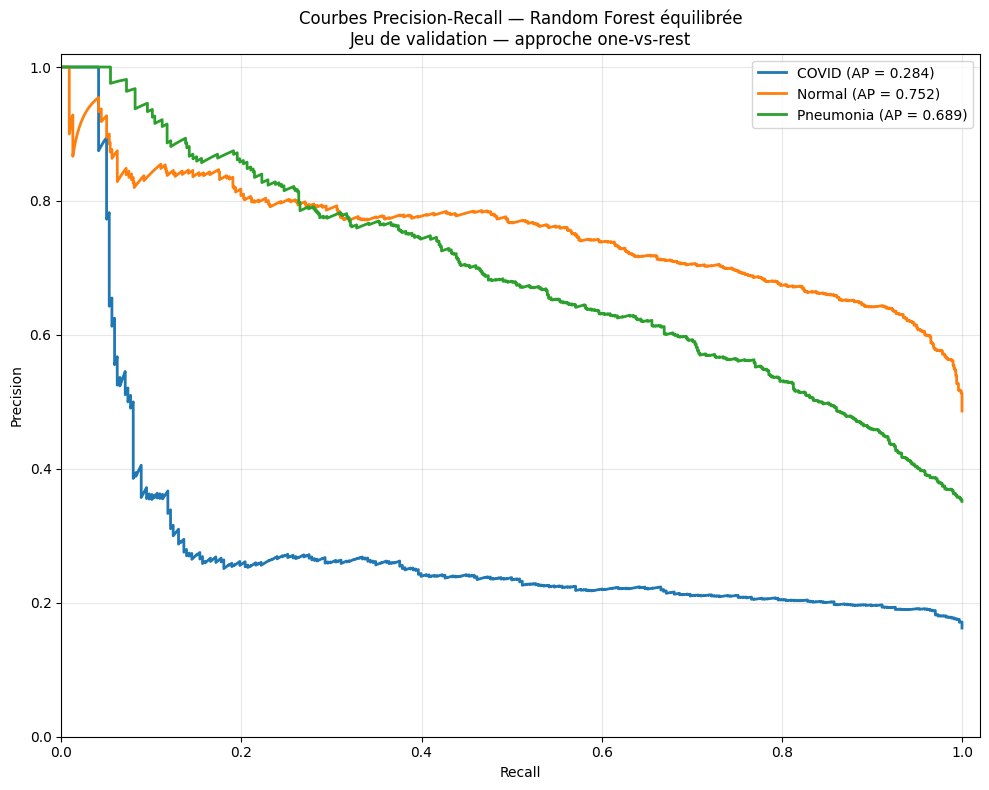

In [24]:
# Courbes Precision / Recall des 4 classes

plt.figure(figsize=(10, 8))

for class_index, class_name in enumerate(class_names):

    # Transformation one-vs-rest :
    # 1 pour la classe étudiée, 0 pour toutes les autres
    y_true_binary = (
        np.asarray(y_val) == class_name
    ).astype(int)

    # Probabilité attribuée à cette classe
    y_score = y_val_proba[:, class_index]

    precision, recall, thresholds = precision_recall_curve(
        y_true_binary,
        y_score
    )

    average_precision = average_precision_score(
        y_true_binary,
        y_score
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AP = {average_precision:.3f})"
        )
    )

plt.title(
    "Courbes Precision-Recall — Random Forest équilibrée\n"
    "Jeu de validation — approche one-vs-rest"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.xlim(0, 1.02)
plt.ylim(0, 1.02)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

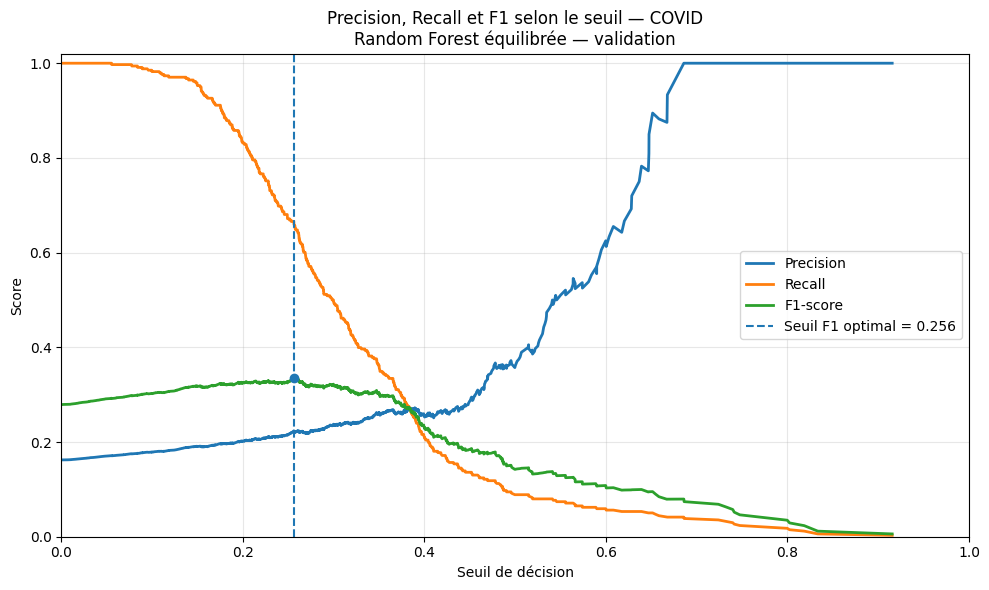

Classe : COVID
Seuil optimal : 0.2562
Precision : 0.2237
Recall : 0.6657
F1-score : 0.3348
--------------------------------------------------


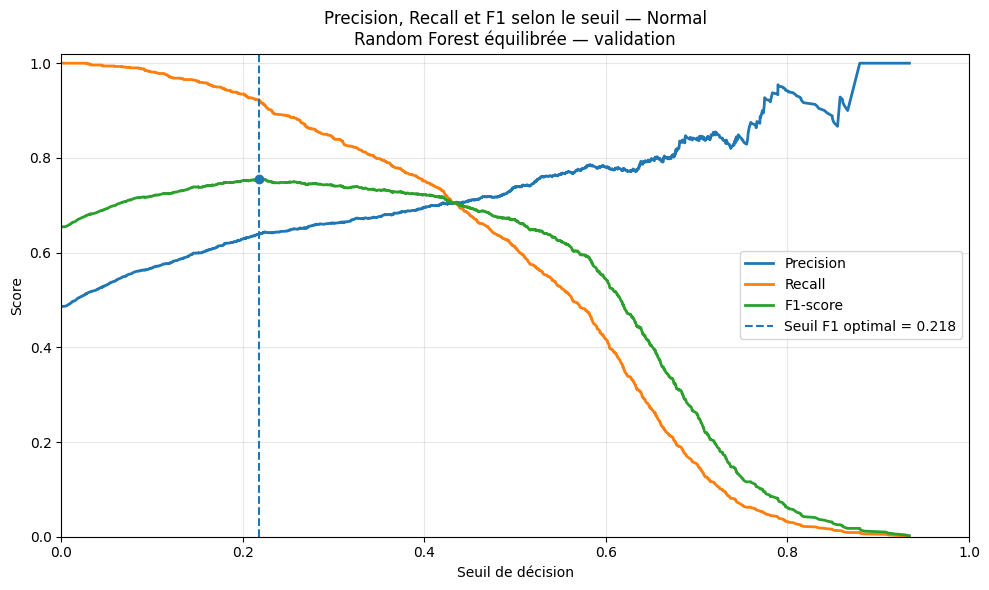

Classe : Normal
Seuil optimal : 0.2179
Precision : 0.6397
Recall : 0.9220
F1-score : 0.7554
--------------------------------------------------


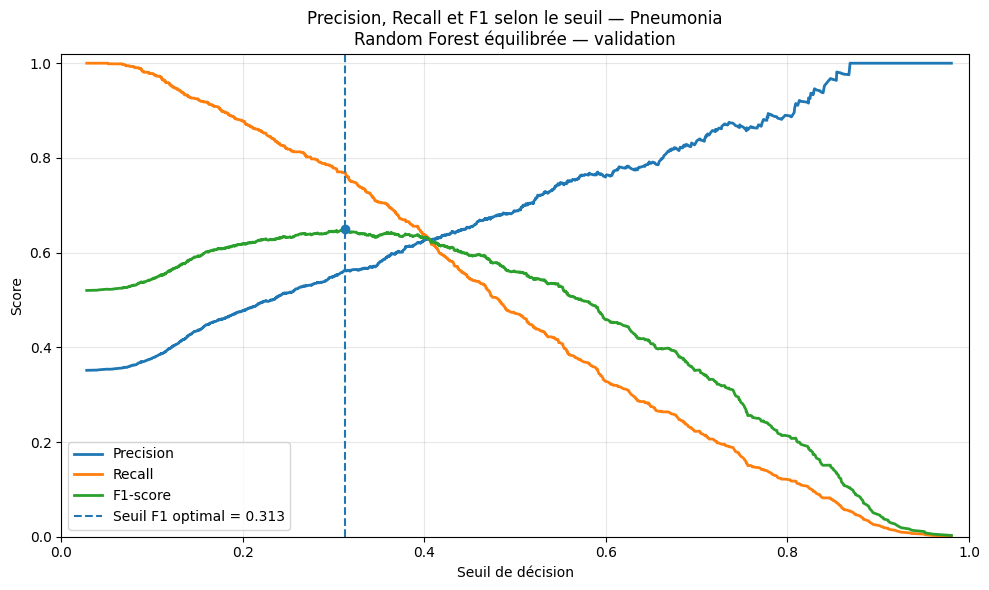

Classe : Pneumonia
Seuil optimal : 0.3130
Precision : 0.5630
Recall : 0.7691
F1-score : 0.6501
--------------------------------------------------


In [25]:
# Precision, Recall et F1 en fonction du seuil

for class_index, class_name in enumerate(class_names):

    y_true_binary = (
        np.asarray(y_val) == class_name
    ).astype(int)

    y_score = y_val_proba[:, class_index]

    precision, recall, thresholds = precision_recall_curve(
        y_true_binary,
        y_score
    )

    # precision et recall contiennent une valeur de plus
    # que thresholds
    precision_by_threshold = precision[:-1]
    recall_by_threshold = recall[:-1]

    f1_by_threshold = (
        2
        * precision_by_threshold
        * recall_by_threshold
        / (
            precision_by_threshold
            + recall_by_threshold
            + 1e-12
        )
    )

    best_index = np.argmax(f1_by_threshold)

    best_threshold = thresholds[best_index]
    best_precision = precision_by_threshold[best_index]
    best_recall = recall_by_threshold[best_index]
    best_f1 = f1_by_threshold[best_index]

    plt.figure(figsize=(10, 6))

    plt.plot(
        thresholds,
        precision_by_threshold,
        label="Precision",
        linewidth=2
    )

    plt.plot(
        thresholds,
        recall_by_threshold,
        label="Recall",
        linewidth=2
    )

    plt.plot(
        thresholds,
        f1_by_threshold,
        label="F1-score",
        linewidth=2
    )

    plt.axvline(
        best_threshold,
        linestyle="--",
        label=(
            f"Seuil F1 optimal = "
            f"{best_threshold:.3f}"
        )
    )

    plt.scatter(
        best_threshold,
        best_f1,
        zorder=5
    )

    plt.title(
        f"Precision, Recall et F1 selon le seuil — {class_name}\n"
        "Random Forest équilibrée — validation"
    )

    plt.xlabel("Seuil de décision")
    plt.ylabel("Score")

    plt.xlim(0, 1)
    plt.ylim(0, 1.02)

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Classe : {class_name}")
    print(f"Seuil optimal : {best_threshold:.4f}")
    print(f"Precision : {best_precision:.4f}")
    print(f"Recall : {best_recall:.4f}")
    print(f"F1-score : {best_f1:.4f}")
    print("-" * 50)

In [26]:
# Récapitulatif des seuils optimaux

threshold_results_rf = []

for class_index, class_name in enumerate(class_names):

    y_true_binary = (
        np.asarray(y_val) == class_name
    ).astype(int)

    y_score = y_val_proba[:, class_index]

    precision, recall, thresholds = precision_recall_curve(
        y_true_binary,
        y_score
    )

    precision_by_threshold = precision[:-1]
    recall_by_threshold = recall[:-1]

    f1_by_threshold = (
        2
        * precision_by_threshold
        * recall_by_threshold
        / (
            precision_by_threshold
            + recall_by_threshold
            + 1e-12
        )
    )

    best_index = np.argmax(f1_by_threshold)

    threshold_results_rf.append({
        "classe": class_name,
        "index_classe": class_index,
        "seuil_optimal_f1": thresholds[best_index],
        "precision_validation": precision_by_threshold[best_index],
        "recall_validation": recall_by_threshold[best_index],
        "f1_validation": f1_by_threshold[best_index],
        "average_precision": average_precision_score(
            y_true_binary,
            y_score
        )
    })

threshold_results_rf_df = pd.DataFrame(
    threshold_results_rf
).round(4)

threshold_results_rf_df

,classe,index_classe,seuil_optimal_f1,precision_validation,recall_validation,f1_validation,average_precision
0,COVID,0,0.2562,0.2237,0.6657,0.3348,0.2838
1,Normal,1,0.2179,0.6397,0.9220,0.7554,0.7522
2,Pneumonia,2,0.3130,0.5630,0.7691,0.6501,0.6886


## Sauvegarde des outputs

In [27]:
# Dossier de sauvegarde
OUTPUT_DIR = PROJECT_ROOT / "outputs_random_forest_3classes"
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Meilleur modèle issu du GridSearchCV
BEST_MODEL_PATH = (
    OUTPUT_DIR
    / "random_forest_3classes_best.joblib"
)

joblib.dump(
    grid_rf.best_estimator_,
    BEST_MODEL_PATH
)

# Résultats complets du GridSearchCV
CV_RESULTS_PATH = (
    OUTPUT_DIR
    / "random_forest_3classes_gridsearch_results.csv"
)

pd.DataFrame(
    grid_rf.cv_results_
).to_csv(
    CV_RESULTS_PATH,
    index=False
)

# Paramètres optimaux
BEST_PARAMS_PATH = (
    OUTPUT_DIR
    / "random_forest_3classes_best_params.txt"
)

with open(
    BEST_PARAMS_PATH,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        f"Meilleur score CV F1 macro : "
        f"{grid_rf.best_score_:.6f}\n"
    )

    file.write(
        f"Meilleurs paramètres : "
        f"{grid_rf.best_params_}\n"
    )

print("Meilleur modèle sauvegardé :", BEST_MODEL_PATH)
print("Résultats GridSearch sauvegardés :", CV_RESULTS_PATH)
print("Meilleurs paramètres sauvegardés :", BEST_PARAMS_PATH)

Meilleur modèle sauvegardé : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\Liora_Covid\outputs_random_forest_3classes\random_forest_3classes_best.joblib
Résultats GridSearch sauvegardés : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\Liora_Covid\outputs_random_forest_3classes\random_forest_3classes_gridsearch_results.csv
Meilleurs paramètres sauvegardés : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\Liora_Covid\outputs_random_forest_3classes\random_forest_3classes_best_params.txt


In [29]:
# Sauvegarde des prédictions et probabilités

np.save(
    OUTPUT_DIR / "y_true_validation_random_forest_3classes.npy",
    y_val.to_numpy()
)

np.save(
    OUTPUT_DIR / "y_pred_validation_random_forest_3classes.npy",
    y_val_pred
)

np.save(
    OUTPUT_DIR / "y_prob_validation_random_forest_3classes.npy",
    y_val_proba
)

np.save(
    OUTPUT_DIR / "y_true_test_random_forest_3classes.npy",
    y_test.to_numpy()
)

np.save(
    OUTPUT_DIR / "y_pred_test_random_forest_3classes.npy",
    y_test_pred
)

# Probabilités sur le jeu de test
y_test_proba = final_model.predict_proba(X_test)

np.save(
    OUTPUT_DIR / "y_prob_test_random_forest_3classes.npy",
    y_test_proba
)

# Noms des classes
np.save(
    OUTPUT_DIR / "classes_random_forest_3classes.npy",
    final_model.named_steps["model"].classes_
)

print("Prédictions sauvegardées dans :", OUTPUT_DIR)

Prédictions sauvegardées dans : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\Liora_Covid\outputs_random_forest_3classes
